# Setup

## Download the database

In [2]:
data_dir = '../data'
data_raw = data_dir + '/raw/filmes.csv'

!wget --no-check-certificate -nc 'https://docs.google.com/uc?export=download&id=1AeYgV89TmYvNC__RDXr8hS0P6WOsChWg' -O $data_raw

File ‘../data/raw/filmes.csv’ already there; not retrieving.


## Install the dependencies

In [3]:
%pip install \
    pandas \
    unidecode \
    spacy \
    matplotlib

!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 2.7 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Import the dataset

In [ ]:
import pandas as pd

In [16]:
df = pd.read_csv(data_raw)
    #.sample(1, random_state=42)

In [17]:
df.shape

(30358, 9)

In [18]:
df.head()

,genres,averageRating,numVotes,sinopse,primaryTitle,startYear,runtimeMinutes,actors_names,directors_names
0,Family,7.1,387992,When two kids find and play a magical board ga...,Jumanji,1995,104,['Robin Williams' 'Jonathan Hyde' 'Jonathan Hy...,['Joe Johnston']
1,Romance,6.7,30265,John and Max resolve to save their beloved bai...,Grumpier Old Men,1995,101,['Walter Matthau' 'Jack Lemmon' 'Burgess Mered...,['Howard Deutch']
2,Romance,6.0,12585,"Based on Terry McMillan's novel, this film fol...",Waiting to Exhale,1995,124,['Gregory Hines' 'Dennis Haysbert' 'Mykelti Wi...,['Forest Whitaker']
3,"Romance,Family",6.1,42555,George Banks must deal not only with his daugh...,Father of the Bride Part II,1995,106,['Steve Martin' 'Martin Short' 'George Newbern...,['Charles Shyer']
4,"Crime,Action",8.3,738636,A group of high-end professional thieves start...,Heat,1995,170,['Al Pacino' 'Robert De Niro' 'Val Kilmer' 'Jo...,['Michael Mann']


# Preprocessing

## Preprocess the data

In [5]:
df.isnull().sum()

# Como não há valores nulos, não removemos nenhuma linha

genres             0
averageRating      0
numVotes           0
sinopse            0
primaryTitle       0
startYear          0
runtimeMinutes     0
actors_names       0
directors_names    0
dtype: int64

### Preprocess genres

In [19]:
df['genres_list'] = df['genres'].apply(lambda x: x.split(','))

<Axes: xlabel='genres_list'>

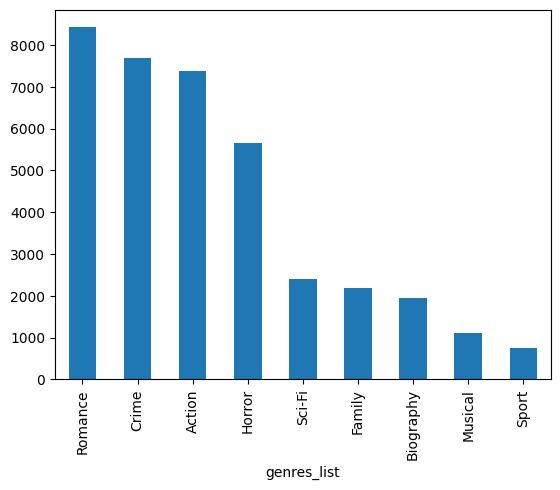

In [20]:
df['genres_list'].explode().value_counts().plot(kind='bar')

### Preprocess synopses

In [7]:
df['sinopse_clean'] = df['sinopse']

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,When two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,John and Max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...","Based on Terry McMillan's novel, this film fol..."
3,George Banks must deal not only with his daugh...,George Banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,A group of high-end professional thieves start...


In [8]:
# lower case
df['sinopse_clean'] = df['sinopse_clean'].apply(str.lower)

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,when two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,john and max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...","based on terry mcmillan's novel, this film fol..."
3,George Banks must deal not only with his daugh...,george banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,a group of high-end professional thieves start...


In [9]:
# normalize special characters

from unidecode import unidecode

df['sinopse_clean'] = [unidecode(c).lower() for c in df['sinopse_clean']]

# they are rare and I'm bad at pandas so I couldn't filter out the difference and show

In [10]:
# remove non-alpha and punctuation, except for apostrophes
import re

df['sinopse_clean'] = [re.sub(r'[^a-z\s\']', '', c) for c in df['sinopse_clean']]

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,when two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,john and max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...",based on terry mcmillan's novel this film foll...
3,George Banks must deal not only with his daugh...,george banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,a group of highend professional thieves start ...


In [11]:
# lemmatize and tokenize

import spacy

nlp = spacy.load('en_core_web_sm')

docs = [nlp(sinopse) for sinopse in df['sinopse_clean']]

df['sinopse_tokens'] = [[token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space] for doc in docs]

df[['sinopse_clean', 'sinopse_tokens']].head()

,sinopse_clean,sinopse_tokens
0,when two kids find and play a magical board ga...,"[kid, find, play, magical, board, game, releas..."
1,john and max resolve to save their beloved bai...,"[john, max, resolve, save, beloved, bait, shop..."
2,based on terry mcmillan's novel this film foll...,"[base, terry, mcmillan, novel, film, follow, d..."
3,george banks must deal not only with his daugh...,"[george, bank, deal, daughter, pregnancy, wife]"
4,a group of highend professional thieves start ...,"[group, highend, professional, thief, start, f..."


In [12]:
# tokenize (nltk)
#   ignore due to spacy lemmatization

#import nltk
#nltk.download('punkt_tab')
#
#df['sinopse_tokens'] = df['sinopse_clean'].apply(nltk.word_tokenize)
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

In [13]:
# remove aphostrophes
#   ignored due to lemmatization

#df['sinopse_tokens'] = df['sinopse_tokens'].apply(lambda x: [t for t in x if t != "'"])
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

In [14]:
# remove stopwords
#   ignore due to lemmatization

#nltk.download('stopwords')
#
#stop_words = set(nltk.corpus.stopwords.words('english'))
#
#df['sinopse_tokens'] = df['sinopse_tokens'].apply(lambda x: [w for w in x if not w in stop_words])
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

## Save the preprocessed data

In [15]:
data_processed_dir = data_dir + '/processed'

!mkdir -p $data_processed_dir

data_processed = data_dir + '/processed/filmes.csv'

df.to_csv(data_processed, index=False)

# Feature Engineering

## Install dependencies

In [1]:
%pip install\
    pandas\
    scikit-learn\
    matplotlib\
    seaborn

Note: you may need to restart the kernel to use updated packages.


## Load dataset

In [2]:
data_dir = '../data'
data_processed_dir = data_dir + '/processed'
data_processed = data_processed_dir + '/filmes.csv'

In [3]:
import pandas as pd

In [4]:
def convert_to_list(x):
    return [t.replace("'", "").replace('"', '') for t in x.strip("[]").split(", ")]

In [5]:
df = pd.read_csv(
    data_processed,
    converters={
        'genres_list': convert_to_list,
        'sinopse_tokens': convert_to_list
    })

In [6]:
df.head()

,genres,averageRating,numVotes,sinopse,primaryTitle,startYear,runtimeMinutes,actors_names,directors_names,genres_list,sinopse_clean,sinopse_tokens
0,Family,7.1,387992,When two kids find and play a magical board ga...,Jumanji,1995,104,['Robin Williams' 'Jonathan Hyde' 'Jonathan Hy...,['Joe Johnston'],[Family],when two kids find and play a magical board ga...,"[kid, find, play, magical, board, game, releas..."
1,Romance,6.7,30265,John and Max resolve to save their beloved bai...,Grumpier Old Men,1995,101,['Walter Matthau' 'Jack Lemmon' 'Burgess Mered...,['Howard Deutch'],[Romance],john and max resolve to save their beloved bai...,"[john, max, resolve, save, beloved, bait, shop..."
2,Romance,6.0,12585,"Based on Terry McMillan's novel, this film fol...",Waiting to Exhale,1995,124,['Gregory Hines' 'Dennis Haysbert' 'Mykelti Wi...,['Forest Whitaker'],[Romance],based on terry mcmillan's novel this film foll...,"[base, terry, mcmillan, novel, film, follow, d..."
3,"Romance,Family",6.1,42555,George Banks must deal not only with his daugh...,Father of the Bride Part II,1995,106,['Steve Martin' 'Martin Short' 'George Newbern...,['Charles Shyer'],"[Romance, Family]",george banks must deal not only with his daugh...,"[george, bank, deal, daughter, pregnancy, wife]"
4,"Crime,Action",8.3,738636,A group of high-end professional thieves start...,Heat,1995,170,['Al Pacino' 'Robert De Niro' 'Val Kilmer' 'Jo...,['Michael Mann'],"[Crime, Action]",a group of highend professional thieves start ...,"[group, highend, professional, thief, start, f..."


## Tf-idf vectorization

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
def identity(x):
    return x

In [16]:
vectorizer = TfidfVectorizer(
    # adjust for the preprocessed tokenized text
    analyzer=identity,
    token_pattern=None,
    lowercase=False,
    
    ngram_range=(1, 2),
    min_df=5
)

X = vectorizer.fit_transform(df['sinopse_tokens'])
feature_names = vectorizer.get_feature_names_out()

/home/srjheam/projects/ufes-cdados-movie-synopsis-clustering/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


In [17]:
X.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(30358, 9388))

In [18]:
feature_names

array(['aaron', 'aback', 'abandon', ..., 'zorro', 'zoya', 'zurich'],
      shape=(9388,), dtype=object)

In [19]:
df_tfidf = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

In [20]:
df_tfidf

,aaron,aback,abandon,abbot,abbott,abby,abduct,abducted,abduction,abductor,...,ziegfeld,zoe,zombie,zombielike,zone,zoo,zoologist,zorro,zoya,zurich
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30353,0.0,0.0,0.06636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30354,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30355,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30356,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dimensionality reduction

In [21]:
from sklearn.decomposition import TruncatedSVD

In [28]:
svd = TruncatedSVD(n_components=250, random_state=42)
svd_matrix = svd.fit_transform(df_tfidf)
print(f"Reduced {df_tfidf.shape[1]} to {svd_matrix.shape[1]} components")

Reduced 9388 to 250 components


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

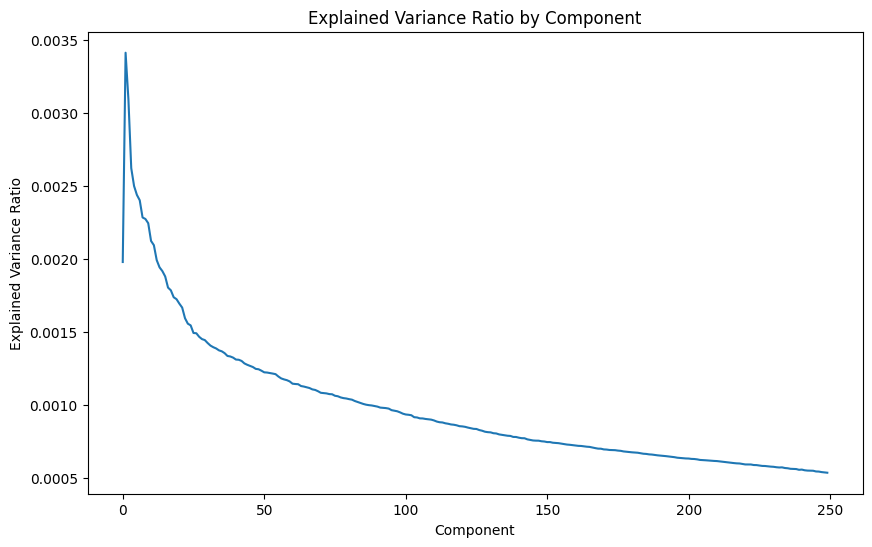

In [29]:
# plot explained variance ratio

plt.figure(figsize=(10, 6))
sns.lineplot(
    x=range(svd.explained_variance_ratio_.shape[0]),
    y=svd.explained_variance_ratio_
)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Component')
plt.show()